In [1]:
# Standard libraries
import os
import re

# Third-party libraries
import numpy as np
import pandas as pd
from tqdm import tqdm

from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import tensorflow as tf

# Project-specific imports
from scripts.utils.data_loader import (
    load_input_data_asarray,
    load_target_data_asarray
)

from scripts.utils.evaluation_plots import (
    plot_binned_iqr,
    contourplot_completeness_reliability,
    plot_completeness_reliability,
    pos_flux_plot,
    plot_image_grid,
    pos_flux_cornerplot_deprecated,

)

from models.architectures.SwinUnet import swin_unet_2d_base

2025-12-08 23:00:06.304385: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-08 23:00:06.362857: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-08 23:00:07.594340: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Setup

In [2]:
# Main dataset dir
ds_dir = "/mnt/g/data/PhD Projects/SR/cosmos/cosmos_spitzer_spire"
ext_source_cat_path = "/mnt/g/data/PhD Projects/SR/obs_catalogs/table_irsa_2mass_ext.csv"

# Model setup
model_name = "SwinUnet"
run_name = "deepSPIRE_default"

model_weights_path = os.path.join("/mnt/d/SPIRE-SR-AI/models/checkpoints", model_name, run_name)

input_shape = [256, 256, 4]
output_shape = [256, 256, 1]
input_classes = ["24", "250", "350", "500"]
batch_size = 16

filter_num_begin = 96     # number of channels in the first downsampling block; it is also the number of embedded dimensions
depth = 4                  # the depth of SwinUNET; depth=4 means three down/upsampling levels and a bottom level 
stack_num_down = 3         # number of Swin Transformers per downsampling level
stack_num_up = 3           # number of Swin Transformers per upsampling level
patch_size = (4, 4)        # Extract 4-by-4 patches from the input image. Height and width of the patch must be equal.
num_heads = [6, 12, 12, 12]   # number of attention heads per down/upsampling level
window_size = [8, 4, 4, 2] # the size of attention window per down/upsampling level
num_mlp = 512              # number of MLP nodes within the Transformer
shift_window=True          # Apply window shifting, i.e., Swin-MSA
model = swin_unet_2d_base(tuple(input_shape), filter_num_begin, depth, stack_num_down, stack_num_up, 
                patch_size, num_heads, window_size, num_mlp, 
                shift_window=shift_window, name='swin_unet')


I0000 00:00:1765231208.571508   26795 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13551 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


## Functions

In [3]:
def SuperResolve(data_X, model):
    batch_its = data_X.shape[0] // batch_size if data_X.shape[0] % batch_size == 0 else data_X.shape[0] // batch_size + 1

    # We store the predictions in memory so we can perform multiprocessing on them later
    pred = np.zeros((data_X.shape[0], ) + tuple(output_shape), dtype=np.float32)

    for batch_idx in range(batch_its):
        # Batch bounds
        start = batch_size * batch_idx
        end = batch_size * (batch_idx + 1) if batch_idx != batch_its - 1 else None

        # Prediction
        pred[start:end] = model(data_X[start:end], training=False).numpy()

    return pred

In [4]:
def load_cutout_wcs(path):
    """Return dict filename → WCS object."""
    fns = [f for f in os.listdir(path) if f.lower().endswith('.fits')]
    wcs_dict = {}

    for fn in tqdm(fns, desc="Loading WCS from all cutouts"):
        hdr = fits.open(os.path.join(path, fn))[0].header
        match = re.search(r'_(\d+)\.fits$', fn)
        if match:
            file_id = int(match.group(1))
        wcs_dict[file_id] = WCS(hdr)
    print(f"Loaded WCS for {len(wcs_dict)} cutouts.")
    return wcs_dict

In [5]:
def skycoord_in_cutout(coord, wcs, nx, ny):
    """Check if a SkyCoord is within the cutout defined by the WCS and image size."""
    x, y = wcs.world_to_pixel(coord)
    return (0 <= x < nx) and (0 <= y < ny)

In [6]:
def create_gridspec_grid(n_rows, n_cols, col_titles=None,
                         wspace=0.1, hspace=0.3,
                         spine_width=1.5):

    figsize = (n_cols * 2.5, n_rows * 2.5)

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(n_rows, n_cols, figure=fig, wspace=wspace, hspace=hspace)

    axes = []
    for r in range(n_rows):
        row_axes = []
        for c in range(n_cols):
            ax = fig.add_subplot(gs[r, c])

            # Turn axis off
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_axis_off()

            # Thicken spines (even though axis is off, spines remain visible)
            for spine in ax.spines.values():
                spine.set_linewidth(spine_width)

            # Add column titles on first row
            if r == 0 and col_titles is not None and c < len(col_titles):
                ax.set_title(col_titles[c], fontsize=12, pad=10)

            row_axes.append(ax)
        axes.append(row_axes)

    return fig, axes


## Code

1. First, we need to load in the WCS information for all cutouts.

In [7]:
wcs_dict = load_cutout_wcs(os.path.join(ds_dir, "Test/24"))

Loading WCS from all cutouts: 100%|██████████| 400/400 [00:05<00:00, 67.38it/s]

Loaded WCS for 400 cutouts.


2. Load the extended source catalog

In [8]:
ext_source_cat = Table.read(ext_source_cat_path).to_pandas()

# Initialise column to hold matching cutout IDs
ext_source_cat['in_cutout_id'] = -1

3. We need to check for which file IDs the extended sources fall within the cutout area.

In [9]:
for fileID, wcs in wcs_dict.items():
    # Get cutout size
    nx, ny = input_shape[0], input_shape[1]

    # Check if any extended source fall within this cutout
    for idx, row in ext_source_cat.iterrows():
        ra = row['ra']
        dec = row['dec']
        coord = SkyCoord(ra=ra*u.degree, dec=dec*u.degree)

        if skycoord_in_cutout(coord, wcs, nx, ny):
            print(f"Extended source {row['designation']} is in cutout {fileID}.")
            ext_source_cat.at[idx, "in_cutout_id"] = fileID

Extended source 10001305+0159595 is in cutout 131.
Extended source 10011677+0217138 is in cutout 207.
Extended source 10025907+0220345 is in cutout 221.
Extended source 10005092+0232127 is in cutout 288.
Extended source 10012057+0133538 is in cutout 7.
Extended source 09575187+0145190 is in cutout 79.
Extended source 10021784+0151237 is in cutout 83.


4. Load in the cutouts input set for SR

In [10]:
ds_path = os.path.join(ds_dir, "Test")
fileIDs = ext_source_cat['in_cutout_id'].values

X, X_wcs = load_input_data_asarray(fileIDs, input_classes, ds_path, tensor_shape_X=tuple(input_shape), get_wcs=True)

5. Super-resolve the cutouts

In [11]:
# Initialise the model weights
ckpt = tf.train.Checkpoint(model=model)
manager_bestmodel = tf.train.CheckpointManager(ckpt, os.path.join(model_weights_path, "BestModel"), max_to_keep=1)
manager_bestmodel.restore_or_initialize()

sr_pred = SuperResolve(X, model)

# Now create a tensor with X and sr_pred aligned by cutout ID for easier analysis
TENSOR = np.concatenate((X, sr_pred), axis=-1)

6. Plot the cutouts in a grid with input and SR output

/tmp/ipykernel_26795/2278626485.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


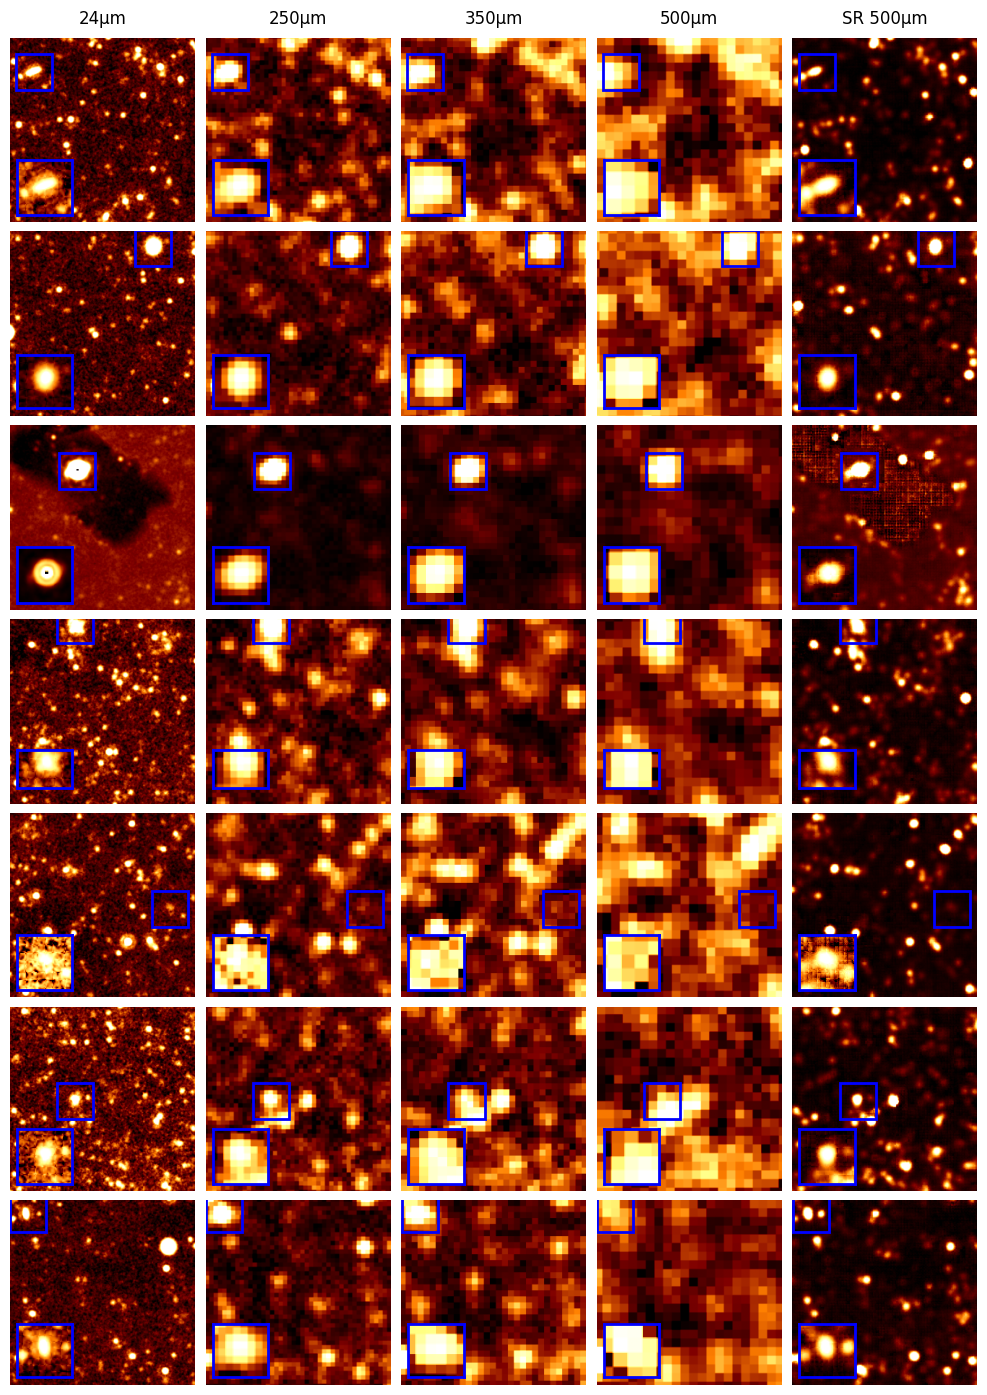

In [13]:
from astropy.visualization import simple_norm

# Find nrow and ncol for plotting grid
n_sources = len(ext_source_cat)
n_rows = n_sources
n_cols = TENSOR.shape[-1]  # Number of channels in TENSOR

# labels
bands = ["24μm", "250μm", "350μm", "500μm", "SR 500μm"]

fig, axes = create_gridspec_grid(n_rows, n_cols, col_titles=bands,
                                wspace=0.05, hspace=0.05,
                                spine_width=1.5)

for row in range(ext_source_cat.shape[0]):
    ext_source_info = ext_source_cat.iloc[row]
    for col in range(n_cols):
        ax = axes[row][col]
        img = TENSOR[row, :, :, col]

        im = ax.imshow(img, origin='lower', cmap='afmhot', vmin=np.percentile(img, 1), vmax=np.percentile(img, 99))

        # create inset centered on extended source
        ra = ext_source_info['ra']
        dec = ext_source_info['dec']
        coord = SkyCoord(ra=ra*u.degree, dec=dec*u.degree)
        x, y = X_wcs[ext_source_info['in_cutout_id']].world_to_pixel(coord)

        inset_size = 50  # pixels
        x_min = int(max(x - inset_size // 2, 0))
        x_max = int(min(x + inset_size // 2, input_shape[1]))
        y_min = int(max(y - inset_size // 2, 0))
        y_max = int(min(y + inset_size // 2, input_shape[0]))

        # Draw rectangle around region
        rect = plt.Rectangle(
            (x_min, y_min),
            inset_size,
            inset_size,
            edgecolor='blue',
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)

        # Inset zoom of the region
        axins = inset_axes(
            ax,
            width="30%",
            height="30%",
            loc='lower left',
            borderpad=0.5,
        )

        cutout = img[y_min:y_max, x_min:x_max]
        norm = simple_norm(cutout, 'asinh', percent=95)
        im_ins = axins.imshow(cutout, origin='lower', cmap='afmhot', norm=norm)
        axins.set_xticks([])
        axins.set_yticks([])

        for spine in axins.spines.values():
            spine.set_edgecolor('blue')
            spine.set_linewidth(2)

        
plt.tight_layout()
plt.savefig("extended_sources_analysis.png", dpi=300, bbox_inches='tight')
plt.show()